# Customer Support Triage - Exploratory Data Analysis
## Dataset: Customer Support Tickets (200k records)

This notebook performs basic EDA on the customer support tickets dataset from Kaggle.

## 1. Import Required Libraries

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_style('whitegrid')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Download Dataset Using Kaggle Hub

In [3]:
# Download latest version
path = kagglehub.dataset_download('mirzayasirabdullah07/customer-support-tickets-dataset-200k-records')

print('Path to dataset files:', path)
print('\n✅ Dataset downloaded successfully')

100%|██████████| 10.6M/10.6M [00:02<00:00, 5.40MB/s]

Extracting files...


Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\mirzayasirabdullah07\customer-support-tickets-dataset-200k-records\versions\1

✅ Dataset downloaded successfully


## 3. Load and Inspect Data

In [4]:
# List files in the dataset path
import os
files = os.listdir(path)
print('Files in dataset:')
for f in files:
    print(f'  - {f}')

# Load the CSV file
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'\n✅ Loaded: {csv_file}')

Files in dataset:
  - customer_support_tickets_200k.csv

✅ Loaded: customer_support_tickets_200k.csv


In [5]:
# Display basic info
print('DATASET SHAPE')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nCOLUMN NAMES:')
print(list(df.columns))

DATASET SHAPE
Rows: 200,000
Columns: 30

COLUMN NAMES:
['ticket_id', 'customer_name', 'customer_email', 'product', 'category', 'issue_description', 'resolution_notes', 'priority', 'status', 'channel', 'region', 'customer_age', 'customer_gender', 'subscription_type', 'customer_tenure_months', 'previous_tickets', 'customer_satisfaction_score', 'first_response_time_hours', 'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date', 'escalated', 'sla_breached', 'operating_system', 'browser', 'payment_method', 'language', 'preferred_contact_time', 'issue_complexity_score', 'customer_segment']


In [6]:
# First few rows
print('FIRST 5 ROWS:')
df.head()

FIRST 5 ROWS:


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,region,customer_age,customer_gender,subscription_type,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,ticket_created_date,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account but the transaction shows failed.,Data synchronization restored after backend service restart.,Urgent,Open,Email,North America,31,Male,Free,36,6,5,30.50,108.36,2023-05-17,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting report generation.,Provided step-by-step troubleshooting instructions and issue resolved.,Urgent,Closed,Email,South America,23,Other,Premium,54,20,5,63.81,87.43,2024-01-06,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to upload a file.,Provided step-by-step troubleshooting instructions and issue resolved.,Medium,Closed,Chat,Europe,47,Female,Premium,60,20,5,16.20,78.50,2022-11-30,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my request and I need clarification.,Provided step-by-step troubleshooting instructions and issue resolved.,Medium,Closed,Social Media,Asia,65,Other,Enterprise,58,18,4,26.38,239.36,2024-03-21,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices properly.,We have reset the account credentials and advised the customer to retry login.,High,Pending Customer,Email,Asia,45,Male,Enterprise,1,8,5,54.98,122.34,2024-08-16,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [7]:
# Data types
print('DATA TYPES:')
print(df.dtypes)

DATA TYPES:
ticket_id                        int64
customer_name                   object
customer_email                  object
product                         object
category                        object
issue_description               object
resolution_notes                object
priority                        object
status                          object
channel                         object
region                          object
customer_age                     int64
customer_gender                 object
subscription_type               object
customer_tenure_months           int64
previous_tickets                 int64
customer_satisfaction_score      int64
first_response_time_hours      float64
resolution_time_hours          float64
ticket_created_date             object
ticket_resolved_date            object
escalated                       object
sla_breached                    object
operating_system                object
browser                         object
payment_metho

## 4. Data Cleaning and Preprocessing

In [8]:
# Check for missing values
print('MISSING VALUES:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string(index=False) if len(missing_df) > 0 else 'No missing values found!')

MISSING VALUES:
 Column  Missing_Count  Missing_Percentage
browser          40023             20.0115


In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'\nDUPLICATE ROWS: {duplicates}')

# Data quality summary
print(f'\nDATA QUALITY SUMMARY:')
print(f'Total rows: {len(df):,}')
print(f'Complete rows: {len(df) - df.isnull().any(axis=1).sum():,}')
print(f'Rows with missing values: {df.isnull().any(axis=1).sum():,}')


DUPLICATE ROWS: 0

DATA QUALITY SUMMARY:
Total rows: 200,000
Complete rows: 159,977
Rows with missing values: 40,023


## 5. Exploratory Data Analysis

In [10]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'CATEGORICAL COLUMNS ({len(categorical_cols)}): {categorical_cols}')
print(f'\nNUMERICAL COLUMNS ({len(numerical_cols)}): {numerical_cols}')

CATEGORICAL COLUMNS (22): ['customer_name', 'customer_email', 'product', 'category', 'issue_description', 'resolution_notes', 'priority', 'status', 'channel', 'region', 'customer_gender', 'subscription_type', 'ticket_created_date', 'ticket_resolved_date', 'escalated', 'sla_breached', 'operating_system', 'browser', 'payment_method', 'language', 'preferred_contact_time', 'customer_segment']

NUMERICAL COLUMNS (8): ['ticket_id', 'customer_age', 'customer_tenure_months', 'previous_tickets', 'customer_satisfaction_score', 'first_response_time_hours', 'resolution_time_hours', 'issue_complexity_score']


In [11]:
# Category distribution
print('CATEGORY DISTRIBUTION:')
if 'category' in df.columns:
    print(df['category'].value_counts())
    print(f'\nUnique categories: {df["category"].nunique()}')

CATEGORY DISTRIBUTION:
category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

Unique categories: 10


In [12]:
# Priority distribution
print('PRIORITY DISTRIBUTION:')
if 'priority' in df.columns:
    print(df['priority'].value_counts())

PRIORITY DISTRIBUTION:
priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64


In [13]:
# Status distribution
print('STATUS DISTRIBUTION:')
if 'status' in df.columns:
    print(df['status'].value_counts())

STATUS DISTRIBUTION:
status
In Progress         40065
Closed              40029
Pending Customer    40014
Resolved            39970
Open                39922
Name: count, dtype: int64


In [14]:
# Channel distribution
print('CHANNEL DISTRIBUTION:')
if 'channel' in df.columns:
    print(df['channel'].value_counts())

CHANNEL DISTRIBUTION:
channel
Web Form        40090
Phone           40073
Chat            40073
Social Media    40038
Email           39726
Name: count, dtype: int64


In [15]:
# Customer demographics
print('CUSTOMER DEMOGRAPHIC SUMMARY:')
if 'customer_age' in df.columns:
    print(f'Age range: {df["customer_age"].min()} - {df["customer_age"].max()}')
    print(f'Average age: {df["customer_age"].mean():.1f}')

if 'customer_gender' in df.columns:
    print(f'\nGender distribution:')
    print(df['customer_gender'].value_counts())

if 'subscription_type' in df.columns:
    print(f'\nSubscription types:')
    print(df['subscription_type'].value_counts())

CUSTOMER DEMOGRAPHIC SUMMARY:
Age range: 18 - 75
Average age: 46.5

Gender distribution:
customer_gender
Other     66795
Male      66606
Female    66599
Name: count, dtype: int64

Subscription types:
subscription_type
Free          50147
Basic         50069
Premium       50052
Enterprise    49732
Name: count, dtype: int64


## 6. Statistical Summary

In [16]:
# Descriptive statistics for numerical columns
print('DESCRIPTIVE STATISTICS:')
df[numerical_cols].describe().round(2)

DESCRIPTIVE STATISTICS:


,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,100000.50,46.47,30.38,9.99,3.00,36.31,120.54,5.50
std,57735.17,16.75,17.33,6.05,1.41,20.65,68.97,2.88
min,1.00,18.00,1.00,0.00,1.00,0.50,1.00,1.00
25%,50000.75,32.00,15.00,5.00,2.00,18.46,60.81,3.00
50%,100000.50,46.00,30.00,10.00,3.00,36.31,120.45,6.00
75%,150000.25,61.00,45.00,15.00,4.00,54.22,180.26,8.00
max,200000.00,75.00,60.00,20.00,5.00,72.00,240.00,10.00


In [17]:
# Customer satisfaction score
print('CUSTOMER SATISFACTION SCORE ANALYSIS:')
if 'customer_satisfaction_score' in df.columns:
    print(df['customer_satisfaction_score'].value_counts().sort_index())
    print(f'\nAverage CSAT: {df["customer_satisfaction_score"].mean():.2f}')

CUSTOMER SATISFACTION SCORE ANALYSIS:
customer_satisfaction_score
1    39756
2    40171
3    40082
4    40086
5    39905
Name: count, dtype: int64

Average CSAT: 3.00


In [18]:
# Response and resolution times
print('RESPONSE & RESOLUTION TIME ANALYSIS:')
if 'first_response_time_hours' in df.columns:
    print(f'\nFirst Response Time (hours):')
    print(df['first_response_time_hours'].describe().round(2))

if 'resolution_time_hours' in df.columns:
    print(f'\nResolution Time (hours):')
    print(df['resolution_time_hours'].describe().round(2))

RESPONSE & RESOLUTION TIME ANALYSIS:

First Response Time (hours):
count    200000.00
mean         36.31
std          20.65
min           0.50
25%          18.46
50%          36.31
75%          54.22
max          72.00
Name: first_response_time_hours, dtype: float64

Resolution Time (hours):
count    200000.00
mean        120.54
std          68.97
min           1.00
25%          60.81
50%         120.45
75%         180.26
max         240.00
Name: resolution_time_hours, dtype: float64


## 7. Visualization of Key Insights

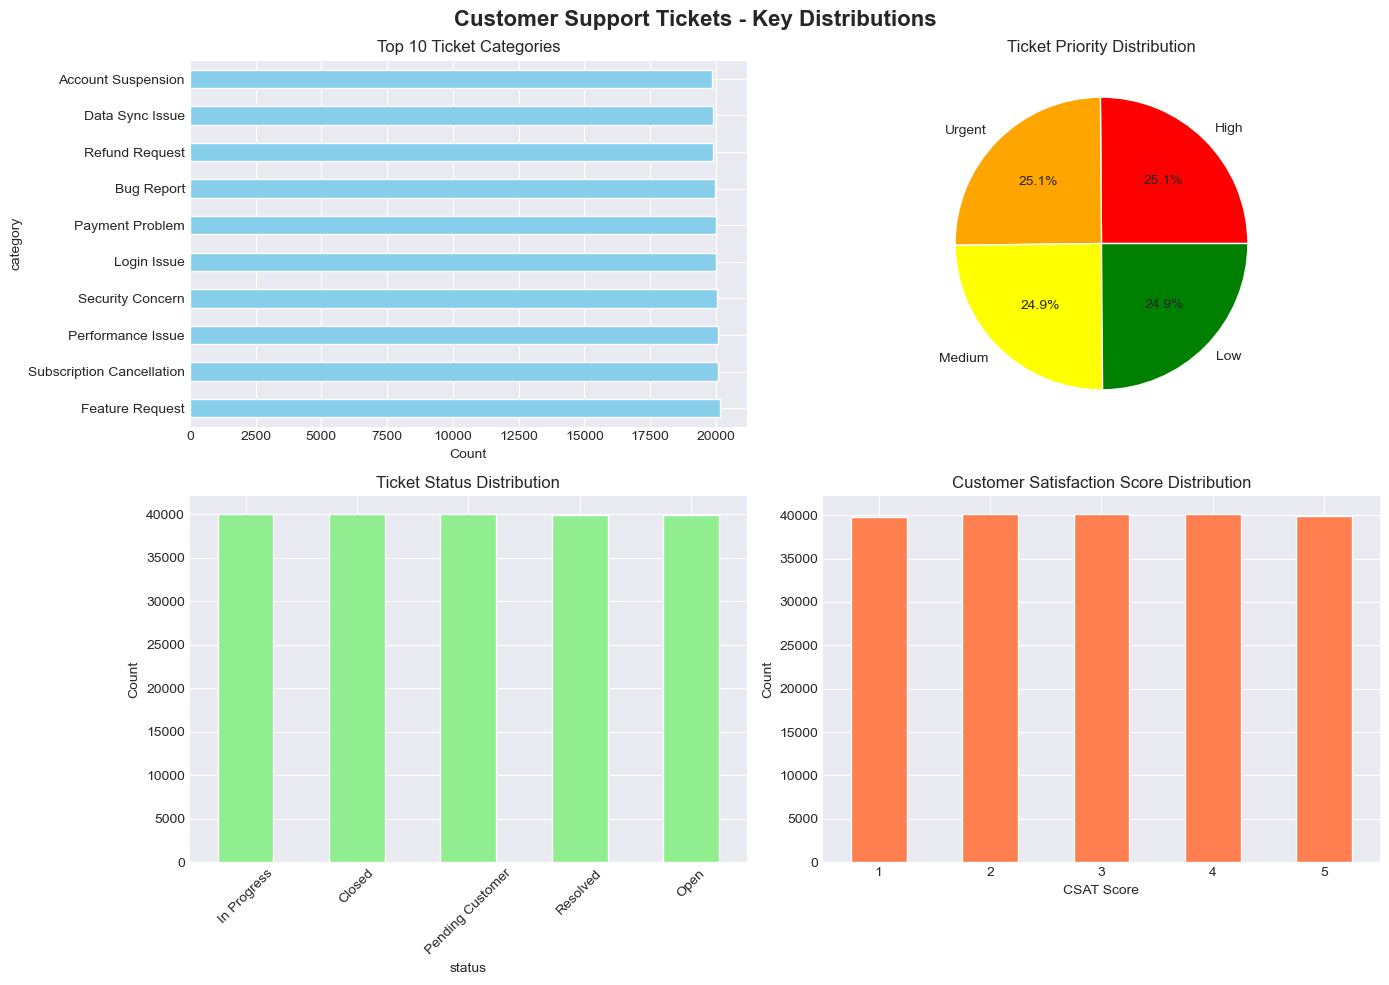

In [19]:
# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Support Tickets - Key Distributions', fontsize=16, fontweight='bold')

# 1. Category distribution
if 'category' in df.columns:
    df['category'].value_counts().head(10).plot(kind='barh', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Top 10 Ticket Categories')
    axes[0, 0].set_xlabel('Count')

# 2. Priority distribution
if 'priority' in df.columns:
    df['priority'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', colors=['red', 'orange', 'yellow', 'green'])
    axes[0, 1].set_title('Ticket Priority Distribution')
    axes[0, 1].set_ylabel('')

# 3. Status distribution
if 'status' in df.columns:
    df['status'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Ticket Status Distribution')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# 4. Customer satisfaction
if 'customer_satisfaction_score' in df.columns:
    df['customer_satisfaction_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='coral')
    axes[1, 1].set_title('Customer Satisfaction Score Distribution')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xlabel('CSAT Score')
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

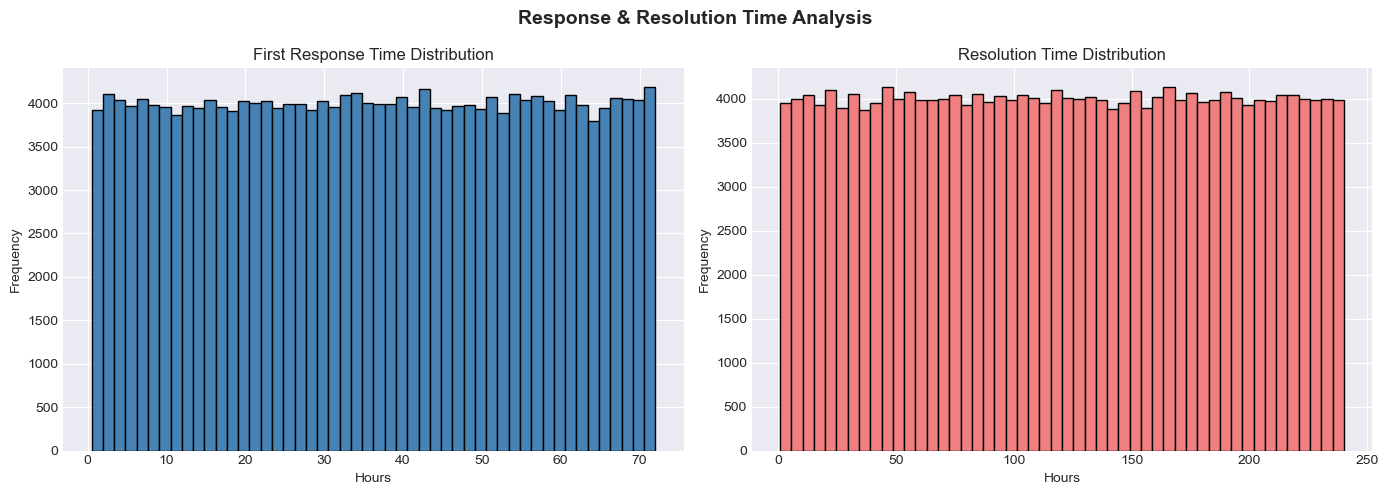

In [20]:
# Response time histogram
if 'first_response_time_hours' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Response & Resolution Time Analysis', fontsize=14, fontweight='bold')
    
    df['first_response_time_hours'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('First Response Time Distribution')
    axes[0].set_xlabel('Hours')
    axes[0].set_ylabel('Frequency')
    
    if 'resolution_time_hours' in df.columns:
        df['resolution_time_hours'].hist(bins=50, ax=axes[1], color='lightcoral', edgecolor='black')
        axes[1].set_title('Resolution Time Distribution')
        axes[1].set_xlabel('Hours')
        axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

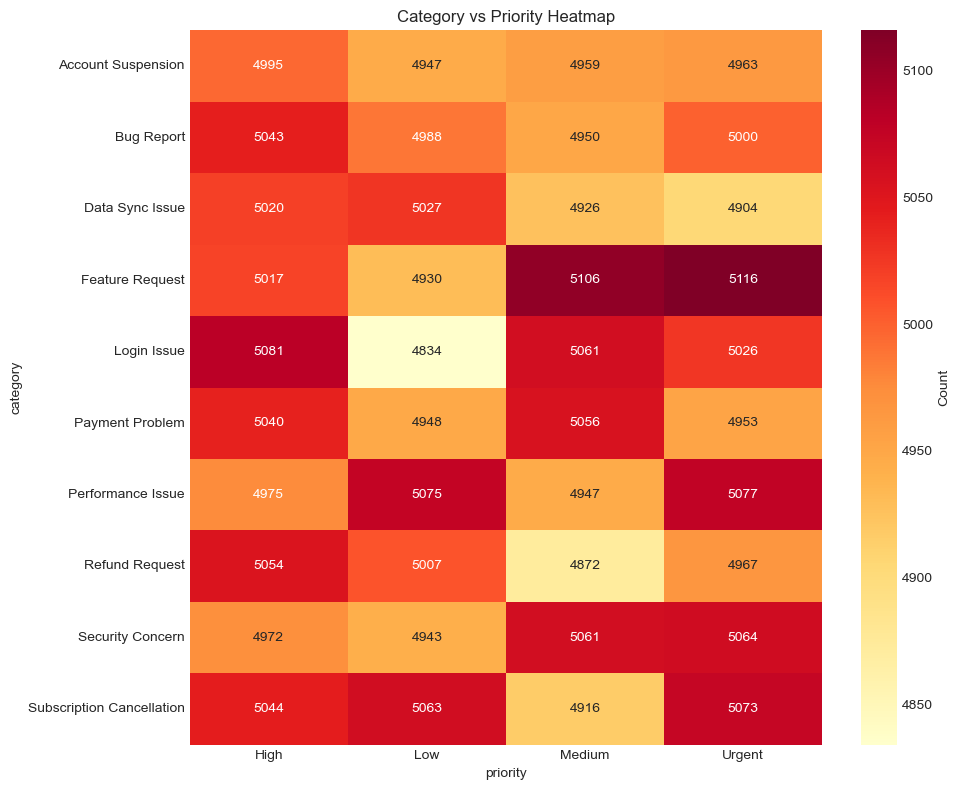

In [21]:
# Category vs Priority heatmap
if 'category' in df.columns and 'priority' in df.columns:
    crosstab = pd.crosstab(df['category'], df['priority'])
    plt.figure(figsize=(10, 8))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
    plt.title('Category vs Priority Heatmap')
    plt.tight_layout()
    plt.show()

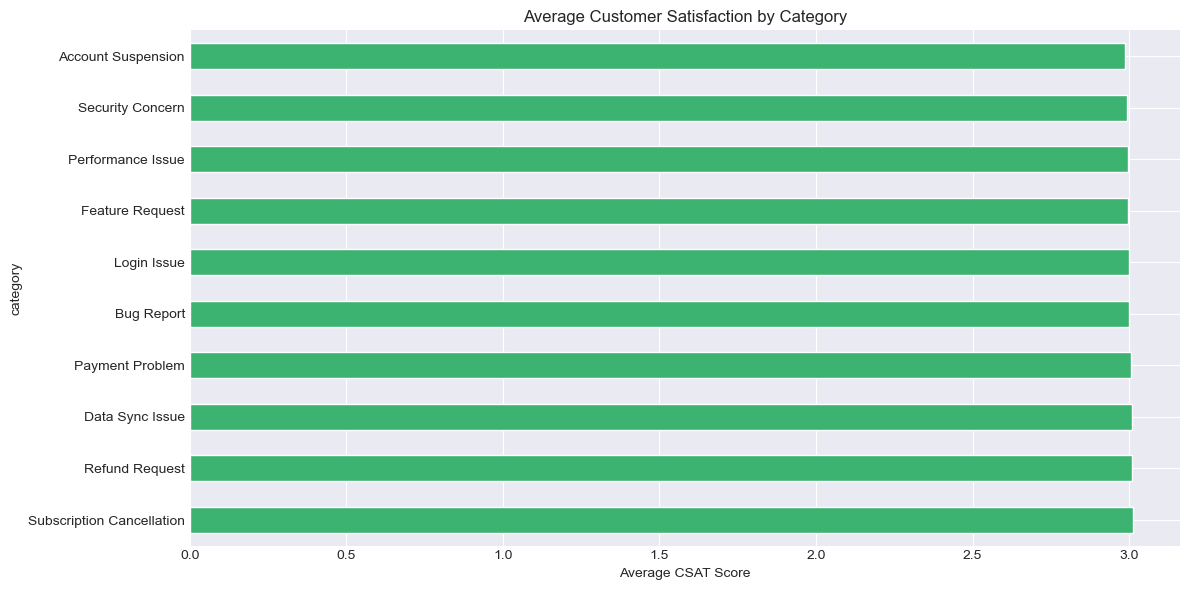

In [22]:
# Category vs CSAT
if 'category' in df.columns and 'customer_satisfaction_score' in df.columns:
    csat_by_category = df.groupby('category')['customer_satisfaction_score'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    csat_by_category.plot(kind='barh', color='mediumseagreen')
    plt.title('Average Customer Satisfaction by Category')
    plt.xlabel('Average CSAT Score')
    plt.tight_layout()
    plt.show()

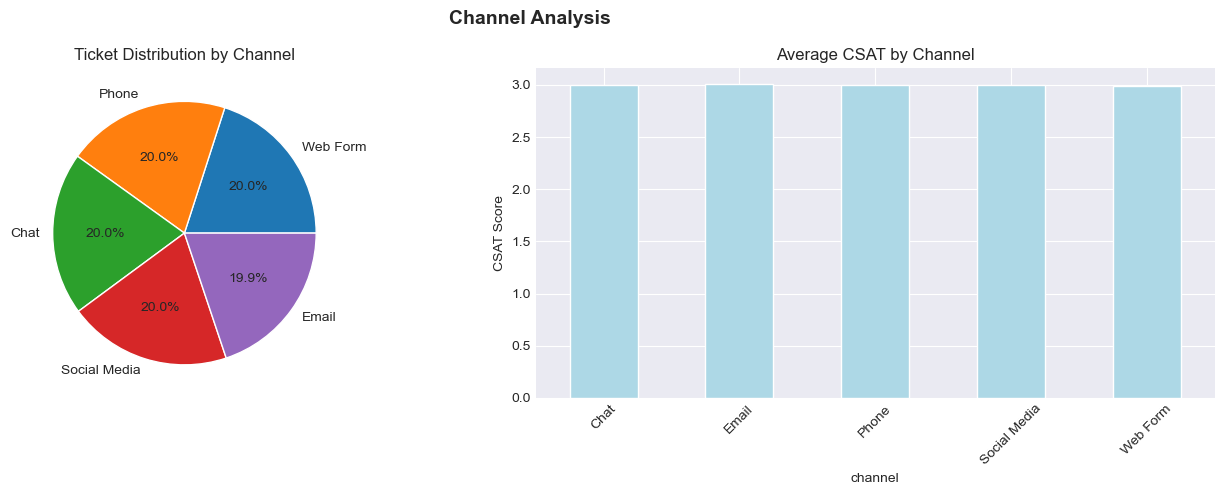

In [24]:
# Channel analysis
if 'channel' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Channel Analysis', fontsize=14, fontweight='bold')
    
    df['channel'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
    axes[0].set_title('Ticket Distribution by Channel')
    axes[0].set_ylabel('')
    
    if 'customer_satisfaction_score' in df.columns:
        csat_by_channel = df.groupby('channel')['customer_satisfaction_score'].mean()
        csat_by_channel.plot(kind='bar', ax=axes[1], color='lightblue')
        axes[1].set_title('Average CSAT by Channel')
        axes[1].set_ylabel('CSAT Score')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

## 8. Summary & Key Insights

In [25]:
print('='*70)
print('EXPLORATORY DATA ANALYSIS SUMMARY')
print('='*70)

print(f'\n📊 DATASET OVERVIEW:')
print(f'   Total Records: {len(df):,}')
print(f'   Total Columns: {df.shape[1]}')
print(f'   Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print(f'\n🎯 KEY METRICS:')
if 'category' in df.columns:
    print(f'   Unique Categories: {df["category"].nunique()}')
if 'priority' in df.columns:
    print(f'   Priority Levels: {df["priority"].nunique()}')
if 'status' in df.columns:
    print(f'   Status Types: {df["status"].nunique()}')
if 'customer_satisfaction_score' in df.columns:
    print(f'   Average CSAT Score: {df["customer_satisfaction_score"].mean():.2f}/5')

print(f'\n✅ DATA QUALITY:')
print(f'   Missing Values: {df.isnull().sum().sum()} total')
print(f'   Duplicate Rows: {df.duplicated().sum()}')
print(f'   Complete Records: {len(df) - df.isnull().any(axis=1).sum():,} ({(1 - df.isnull().any(axis=1).sum()/len(df))*100:.1f}%)')

print('\n' + '='*70)

EXPLORATORY DATA ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   Total Records: 200,000
   Total Columns: 30
   Memory Usage: 277.34 MB

🎯 KEY METRICS:
   Unique Categories: 10
   Priority Levels: 4
   Status Types: 5
   Average CSAT Score: 3.00/5

✅ DATA QUALITY:
   Missing Values: 40023 total
   Duplicate Rows: 0
   Complete Records: 159,977 (80.0%)

